In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from sklearn import metrics
from keras import optimizers

In [38]:
red = pd.read_csv("redwinequality.csv", sep=";")
white = pd.read_csv("whitewinequality.csv", sep=";")

In [39]:
red['type'] = 1
white['type'] = 0

wines = pd.concat([red, white], ignore_index=True)
wines.dropna(inplace=True)

In [40]:
X = wines.drop('type', axis=1)
Y = wines.loc[:, ['type']]

In [41]:
X_train, X_test, Y_train,  Y_test = train_test_split(
    X,
    Y,
    test_size=0.15,
    random_state=42

)

In [ ]:
model = Sequential()
model.add(Dense(12, activation='relu', input_dim=12))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
opt = optimizers.Adam(learning_rate=0.00003)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy', 'recall']) 

c:\Users\alexa\.vscode\portfolio\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train, Y_train, epochs=10000, batch_size=20, verbose=1)

Epoch 1/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 836us/step - accuracy: 0.9277 - loss: 0.2242 - recall: 0.7864
Epoch 2/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 857us/step - accuracy: 0.9457 - loss: 0.1523 - recall: 0.8237
Epoch 3/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 832us/step - accuracy: 0.9524 - loss: 0.1297 - recall: 0.8566
Epoch 4/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 826us/step - accuracy: 0.9658 - loss: 0.1034 - recall: 0.9022
Epoch 5/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 4s 809us/step - accuracy: 0.9679 - loss: 0.0999 - recall: 0.9119
Epoch 6/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 4s 811us/step - accuracy: 0.9699 - loss: 0.0941 - recall: 0.9208
Epoch 7/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 936us/step - accuracy: 0.9732 - loss: 0.0875 - recall: 0.9276
Epoch 8/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 910us/step - accuracy: 0.9725 - loss: 0.0883 - recall: 0.9238
Epoch 9/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 866us/step - accuracy: 0.9743 - loss: 0.0861 - recall: 0.9291
Epoch 10/100
5522/5522 ━━━━━

In [110]:
y_pred = model.predict(X_test)
y_pred_labels = pd.DataFrame((y_pred >= 0.5).astype(int)).rename(columns={0: 'predicted_type'})

tester = pd.concat([y_pred_labels, Y_test.reset_index()], axis=1).drop('index', axis=1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


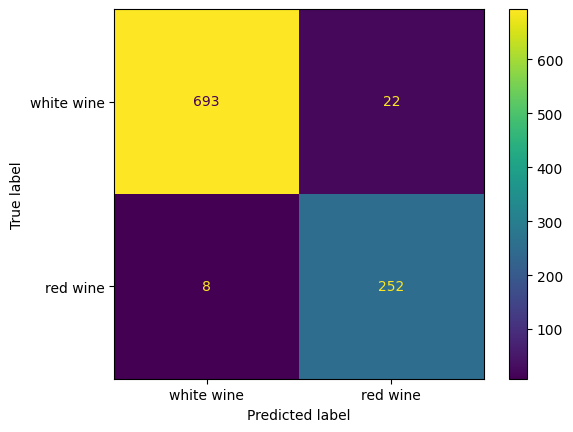

In [111]:
matrix = metrics.confusion_matrix(tester['type'], tester['predicted_type'])
display = metrics.ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=('white wine', 'red wine'))
display.plot()
plt.show()